In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset

In [6]:
df  = pd.read_csv('data.csv')

print(df.head())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [7]:
print(df.describe())


              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.868549      353.221224   
min     50003.700000    

In [9]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273,2021-10-01
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833,2019-07-01
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709,2019-09-01
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754,2020-05-01


In [11]:
df =df.sort_values('Date')
df.set_index('Date', inplace=True)
df

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
Date,,,,,,,,,,,,
2015-01-01,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390
2015-01-01,2015,1,Middle East,Model Y,10348,10835,85599.95,82,488,757.47,Estimated (Region),5991
2015-01-01,2015,1,Europe,Model Y,10835,11723,62939.81,120,718,1166.93,Official (Quarter),12301
2015-01-01,2015,1,North America,Model Y,12170,12958,70386.04,120,696,1270.55,Official (Quarter),4673
2015-01-01,2015,1,Europe,Model 3,7597,8376,80810.67,75,417,475.19,Interpolated (Month),8942
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-01,2025,12,Asia,Cybertruck,7317,7883,74218.07,100,583,639.87,Interpolated (Month),14412
2025-12-01,2025,12,North America,Model X,6293,6849,67797.67,82,461,435.16,Estimated (Region),8860
2025-12-01,2025,12,Europe,Model S,11374,11433,82811.35,60,341,581.78,Official (Quarter),4642


In [14]:
df['Deliveries_Lag_1'] = df['Estimated_Deliveries'].shift(1)
df['Production_Lag_1'] = df['Production_Units'].shift(1)
df['Deliveries_Rolling_Mean_3'] = df['Estimated_Deliveries'].shift(1).rolling(window=3).mean()
df['Production_Rolling_Mean_3'] = df['Production_Units'].shift(1).rolling(window=3).mean()

In [1]:
df

NameError: name 'df' is not defined

In [20]:
print(df[[ 'Region', 'Estimated_Deliveries', 'Deliveries_Lag_1', 'Deliveries_Rolling_Mean_3']].head(5))
df.dropna(inplace=True)


                   Region  Estimated_Deliveries  Deliveries_Lag_1  \
Date                                                                
2015-01-01  North America                 12170           10835.0   
2015-01-01         Europe                  7597           12170.0   
2015-01-01    Middle East                  7419            7597.0   
2015-01-01           Asia                  9537            7419.0   
2015-01-01           Asia                 11325            9537.0   

            Deliveries_Rolling_Mean_3  
Date                                   
2015-01-01               11209.666667  
2015-01-01               11117.666667  
2015-01-01               10200.666667  
2015-01-01                9062.000000  
2015-01-01                8184.333333  


### 1. Target Variable Distribution
This plot isolates the distribution of our target variable, Estimated_Deliveries. It helps us check if our target values are normally distributed or heavily skewed.

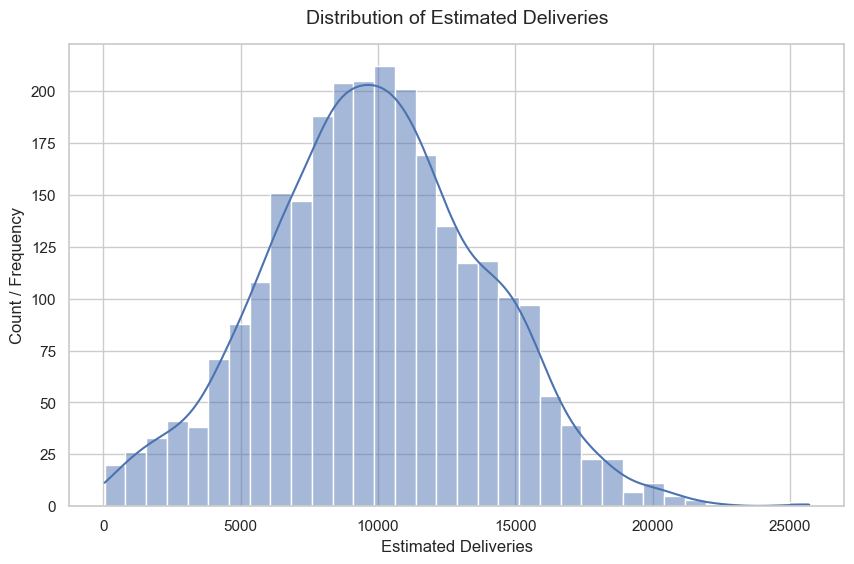

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean styling theme
sns.set_theme(style="whitegrid")

# Create a dedicated figure for the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Estimated_Deliveries'], kde=True)
plt.title('Distribution of Estimated Deliveries', fontsize=14, pad=15)
plt.xlabel('Estimated Deliveries', fontsize=12)
plt.ylabel('Count / Frequency', fontsize=12)
plt.show()

 ### 2. Production vs. Deliveries Scatter Plot
This chart helps us inspect the relationship between Production_Units and Estimated_Deliveries to see if there is a linear relationship. The points are colored by vehicle model to identify structural differences.

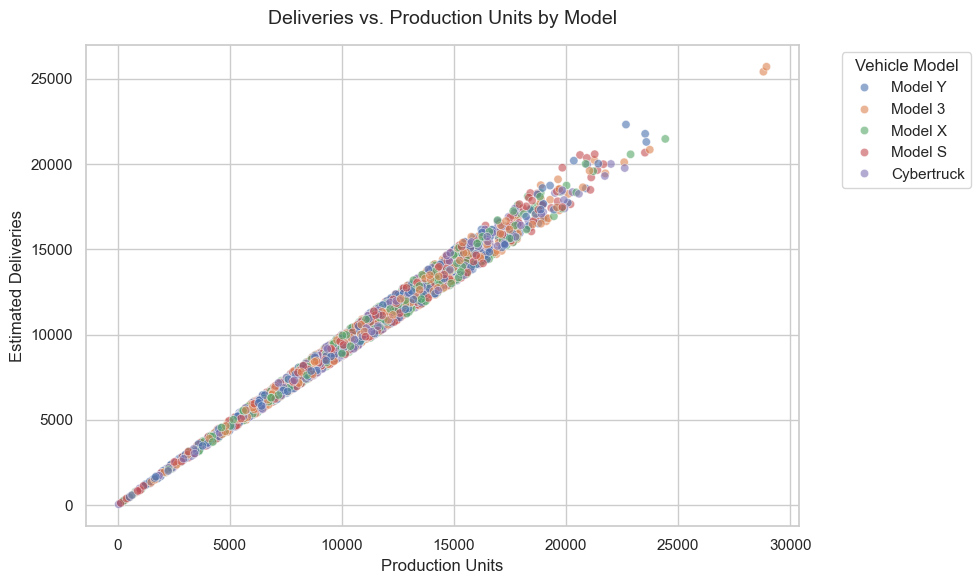

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Production_Units', 
    y='Estimated_Deliveries', 
    hue='Model', 
    alpha=0.6
)
plt.title('Deliveries vs. Production Units by Model', fontsize=14, pad=15)
plt.xlabel('Production Units', fontsize=12)
plt.ylabel('Estimated Deliveries', fontsize=12)
plt.legend(title='Vehicle Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3. Deliveries by Vehicle Model Boxplot
This plot shows the operational scale, median volume, and spread for each individual vehicle model in your dataset.

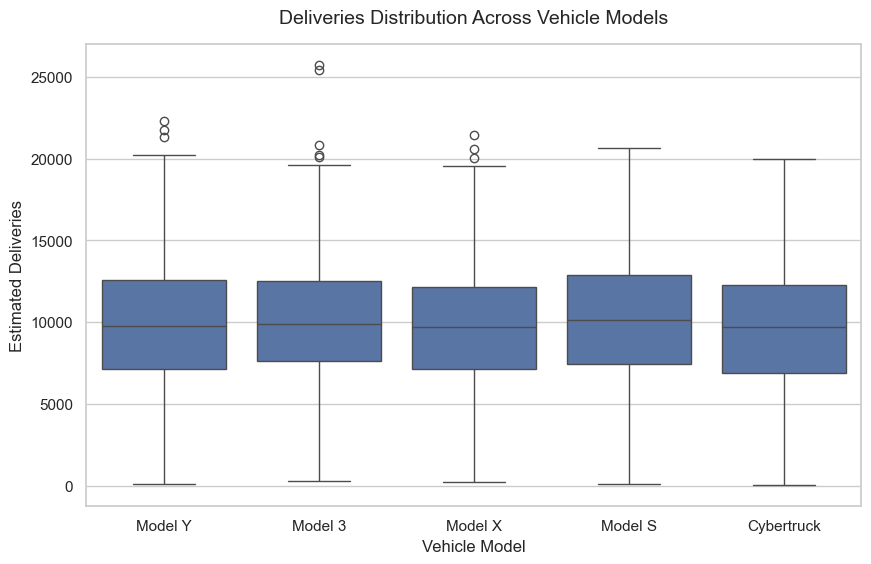

In [26]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Model', y='Estimated_Deliveries')
plt.title('Deliveries Distribution Across Vehicle Models', fontsize=14, pad=15)
plt.xlabel('Vehicle Model', fontsize=12)
plt.ylabel('Estimated Deliveries', fontsize=12)
plt.show()


### 4. Full Feature Correlation HeatmapThis 
matrix displays the linear correlation coefficient between every single numeric variable in your dataset. We look for values close to $+1.00$ or $-1.00$ to identify strong patterns and look for high correlations between features to catch potential multicollinearity issues.

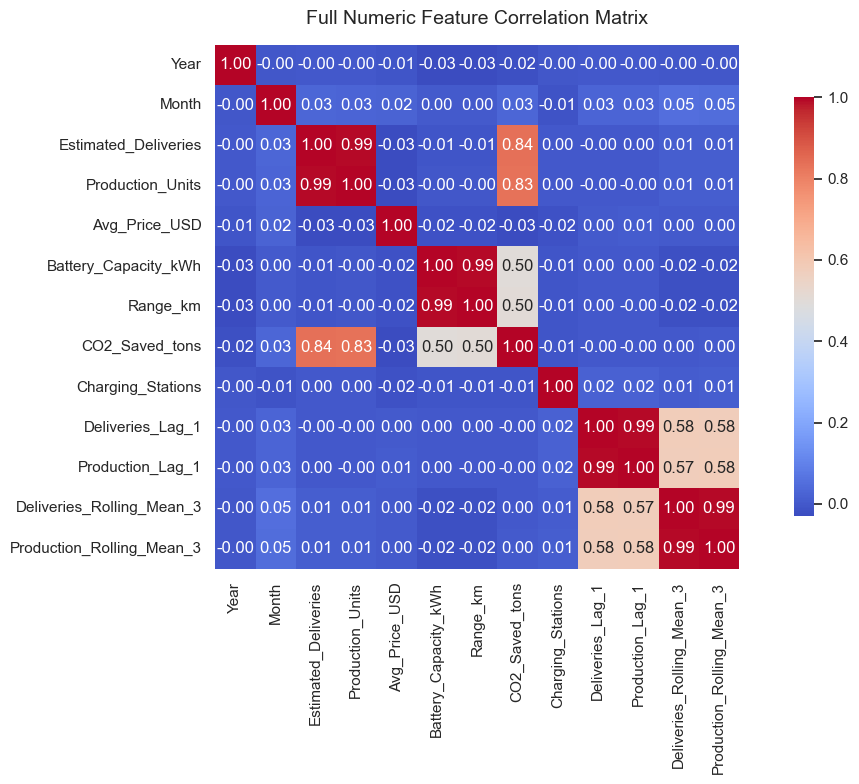

In [28]:
plt.figure(figsize=(12, 8))

# Filter out only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
plt.title('Full Numeric Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### Define target (what we want to predict) and features

In [29]:
 
target = 'Estimated_Deliveries'
 
features = [
    'Region', 'Model', 'Production_Units', 'Avg_Price_USD', 
    'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
    'Deliveries_Lag_1', 'Production_Lag_1', 
    'Deliveries_Rolling_Mean_3', 'Production_Rolling_Mean_3'
]

X = df[features]
y = df[target]
 
split_index = int(len(df) * 0.80)
 
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("--- Chronological Split Complete ---")
print(f"Training features shape: {X_train.shape} (Covers oldest data)")
print(f"Testing features shape:  {X_test.shape} (Covers newest data)")
print(f"Training timeline range: {X_train.index.min()} to {X_train.index.max()}")
print(f"Testing timeline range:  {X_test.index.min()} to {X_test.index.max()}")

--- Chronological Split Complete ---
Training features shape: (2109, 12) (Covers oldest data)
Testing features shape:  (528, 12) (Covers newest data)
Training timeline range: 2015-01-01 00:00:00 to 2023-10-01 00:00:00
Testing timeline range:  2023-10-01 00:00:00 to 2025-12-01 00:00:00


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# 1. Identify which columns need scaling vs encoding
numeric_features = [
    'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 
    'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
    'Deliveries_Lag_1', 'Production_Lag_1', 
    'Deliveries_Rolling_Mean_3', 'Production_Rolling_Mean_3'
]

categorical_features = ['Region', 'Model']
 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
 
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

 
pipeline.fit(X_train, y_train)
 

--- Pipeline Successfully Constructed and Trained ---
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Production_Units',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations',
                                                   'Deliveries_Lag_1',
                                                   'Production_Lag_1',
                                                   'Deliveries_Rolling_Mean_3',
                                                   'Production_Rolling_Mean_3']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                    

In [32]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Deliveries_Lag_1,Production_Lag_1,Deliveries_Rolling_Mean_3,Production_Rolling_Mean_3
Date,,,,,,,,,,,,,,,,
2015-01-01,2015,1,North America,Model Y,12170,12958,70386.04,120,696,1270.55,Official (Quarter),4673,10835.0,11723.0,11209.666667,12147.666667
2015-01-01,2015,1,Europe,Model 3,7597,8376,80810.67,75,417,475.19,Interpolated (Month),8942,12170.0,12958.0,11117.666667,11838.666667
2015-01-01,2015,1,Middle East,Model X,7419,8000,79927.87,75,413,459.61,Official (Quarter),4294,7597.0,8376.0,10200.666667,11019.000000
2015-01-01,2015,1,Asia,Model S,9537,10093,68994.43,82,484,692.39,Official (Quarter),7281,7419.0,8000.0,9062.000000,9778.000000
2015-01-01,2015,1,Asia,Cybertruck,11325,11887,54449.08,60,339,575.88,Estimated (Region),6902,9537.0,10093.0,8184.333333,8823.000000


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
  
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE):      {mae:.2f}")
print(f"Root Mean Squared Error (RMSE):  {rmse:.2f}")
print(f"R-squared (R2) Score:            {r2:.4f}")

 

Mean Absolute Error (MAE):      321.19
Root Mean Squared Error (RMSE):  391.07
R-squared (R2) Score:            0.9887


In [35]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


tscv = TimeSeriesSplit(n_splits=5)

param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])
ridge_search = GridSearchCV(ridge_pipeline, param_grid, cv=tscv, scoring='neg_root_mean_squared_error')
ridge_search.fit(X_train, y_train)

# 4. Tune a Lasso Pipeline
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000))
])
lasso_search = GridSearchCV(lasso_pipeline, param_grid, cv=tscv, scoring='neg_root_mean_squared_error')
lasso_search.fit(X_train, y_train)

# 5. Evaluate Best Models on Test Data
best_ridge = ridge_search.best_estimator_
best_lasso = lasso_search.best_estimator_

print("--- Regularized Models Performance ---")
print(f"Best Ridge Alpha: {ridge_search.best_params_['model__alpha']}")
print(f"Ridge Test RMSE:  {np.sqrt(mean_squared_error(y_test, best_ridge.predict(X_test))):.2f}")

print(f"\nBest Lasso Alpha: {lasso_search.best_params_['model__alpha']}")
print(f"Lasso Test RMSE:  {np.sqrt(mean_squared_error(y_test, best_lasso.predict(X_test))):.2f}")

--- Regularized Models Performance ---
Best Ridge Alpha: 0.1
Ridge Test RMSE:  391.02

Best Lasso Alpha: 10.0
Lasso Test RMSE:  394.67
